In [1]:
## IMPORTS AND SETUP
# Imports
import matplotlib.pyplot as plt
import numpy as np
import os
import tensorflow as tf
import datetime
import zipfile
import pandas as pd
from PIL import Image
import tensorflow_datasets as tfds
import wandb
import datetime
from wandb.integration.keras import WandbMetricsLogger
from dotenv import load_dotenv
from concurrent.futures import ThreadPoolExecutor, as_completed

load_dotenv('../.env')

WANDB_API_KEY = os.getenv("API_KEY")

# Forcer TensorFlow à utiliser le GPU
gpus = tf.config.list_physical_devices('GPU')
# if gpus:
#     try:
#         for gpu in gpus:
#             tf.config.experimental.set_memory_growth(gpu, True)
#     except RuntimeError as e:
#         print(e)

    
# Tensorboard setup
# %load_ext tensorboard




2025-04-11 16:56:08.446194: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-11 16:56:08.544748: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-04-11 16:56:08.582417: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-04-11 16:56:08.593088: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-04-11 16:56:08.658608: I tensorflow/core/platform/cpu_feature_guar

In [2]:
# Paramètres
path = "../Dataset"
excluded_folder = "Dataset Leyanda_Project"  # Dossier à exclure
batch_size = 32
img_height = 180
img_width = 180
learning_rate= 0.001
num_epochs = 10
model_name = "CNN_Dropout_3_0.3_BatchNormalization" 



In [3]:
wandb.login(key=WANDB_API_KEY , relogin=True) 
run = wandb.init(
    project="Leyanda",
    config={
        "name": model_name +"_"+ datetime.datetime.now().strftime("%Y%m%d-%H%M%S"),
        "model_name": model_name,
        "learning_rate": learning_rate,
        "epochs": num_epochs,
    }
)

log_dir = f"logs/fit/{model_name}/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = tf.keras.callbacks.TensorBoard(
    log_dir=log_dir,
    histogram_freq=1,
    write_graph=True,
    update_freq='epoch'
)

wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Currently logged in as: tom-antoine (tom-antoine-cesi) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [4]:


# Vérifier le chemin et le contenu
print(f"Chemin absolu : {os.path.abspath(path)}")
if not os.path.exists(path):
    raise ValueError("Le chemin spécifié n'existe pas.")
else:
    print(f"Contenu du dossier principal : {os.listdir(path)}")

# Exclure le dossier spécifié
subfolders = [f for f in os.listdir(path) if os.path.isdir(os.path.join(path, f)) and f != excluded_folder]
print(f"Sous-dossiers utilisés pour le dataset : {subfolders}")

# Créer un dataset optimisé à partir du répertoire
try:
    dataset = tf.keras.utils.image_dataset_from_directory(
        path,
        labels="inferred",  # Les labels sont inférés à partir des noms des sous-dossiers
        label_mode="int",  # Labels sous forme d'entiers
        class_names=subfolders,  # Spécifier les classes à inclure
        color_mode="rgb",  # Images en RGB
        batch_size=batch_size,
        image_size=(img_height, img_width),  # Redimensionner les images
        shuffle=True,
        seed=123,
        validation_split=None,  # Pas de validation split ici
        subset=None,
        interpolation="bilinear",
        follow_links=False
    )

    # Afficher les classes détectées
    class_names = dataset.class_names
    print(f"Classes détectées : {class_names}")

    # Précharger les données pour une meilleure performance
    dataset = dataset.prefetch(buffer_size=tf.data.AUTOTUNE)

    # Afficher un exemple
    for images, labels in dataset.take(1):
        print(f"Images batch shape : {images.shape}")
        print(f"Labels batch : {labels.numpy()}")

except Exception as e:
    print(f"Erreur lors de la création du dataset : {e}")

Chemin absolu : /tf/projet/Dataset
Contenu du dossier principal : ['Dataset Livrable 2', 'Painting', 'Photo', 'Schematics', 'Sketch', 'Text']
Sous-dossiers utilisés pour le dataset : ['Painting', 'Photo', 'Schematics', 'Sketch', 'Text']


KeyboardInterrupt: 

In [33]:
# Proportions des splits
train_split = 0.8
val_split = 0.1
test_split = 0.1

# Calculer les tailles
dataset_size = tf.data.experimental.cardinality(dataset).numpy()  # Plus rapide que len(dataset)
train_size = int(train_split * dataset_size)
val_size = int(val_split * dataset_size)

# Mélanger le dataset
# dataset = dataset.shuffle(buffer_size=500, seed=123)

# Diviser le dataset
train_ds = dataset.take(train_size)
val_ds = dataset.skip(train_size).take(val_size)
test_ds = dataset.skip(train_size + val_size)

# Ajouter prefetch pour optimiser les performances
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

In [34]:
## MODEL CREATION

def create_model(img_height = 180, img_width = 180, num_classes = 5):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(img_height, img_width, 3)),
        tf.keras.layers.Rescaling(1./255),
        tf.keras.layers.Conv2D(16, 3, padding='same', activation='relu'),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Dropout(0.3),  
        
        tf.keras.layers.Conv2D(32, 3, padding='same', activation='relu'),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Dropout(0.3),  
        
        tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu'),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Dropout(0.3),  
        
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.3),  
        
        tf.keras.layers.Dense(num_classes)
    ])
    model.compile(optimizer='adam',
                  loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                  metrics=['accuracy'])
                  
    model.save(f'./models/{model_name}.keras', include_optimizer=False)
                  
    return model

model = create_model(img_height, img_width, len(class_names))


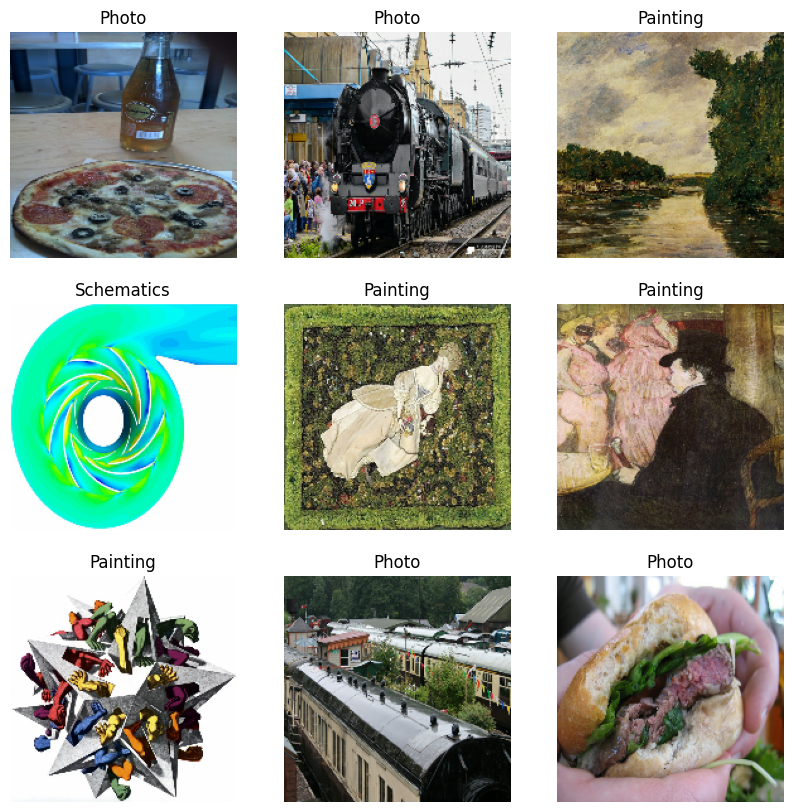

In [35]:
plt.figure(figsize=(10, 10))

# Re-initialize the dataset iterator
train_ds_iter = iter(train_ds)  # Create a fresh iterator from the dataset

# Fetch one batch of images and labels
images, labels = next(train_ds_iter)

# Display up to 9 images
for i in range(min(9, len(images))):  # Limit to 9 images
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

In [36]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_2 (Rescaling)         │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 180, 180, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 90, 90, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 90, 90, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 90, 90, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 45, 45, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 45, 45, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 30976)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     3,965,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,989,285 (15.22 MB)

 Trainable params: 3,989,285 (15.22 MB)

 Non-trainable params: 0 (0.00 B)

In [38]:
import wandb
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import ConfusionMatrixDisplay

class ConfusionMatrixCallback(tf.keras.callbacks.Callback):
    def __init__(self, val_data, class_names):
        super().__init__()
        self.val_data = val_data
        self.class_names = class_names

    def on_epoch_end(self, epoch, logs=None):
        y_true, y_pred = [], []

        # Collect true labels and predictions
        for images, labels in self.val_data:
            preds = self.model.predict(images)
            y_true.extend(labels.numpy())
            y_pred.extend(np.argmax(preds, axis=1))

        # Generate confusion matrix
        cm = confusion_matrix(y_true, y_pred)
        fig, ax = plt.subplots(figsize=(6, 6))
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=self.class_names)
        disp.plot(ax=ax, xticks_rotation=45)
        plt.title(f"Confusion Matrix - Epoch {epoch + 1}")
        plt.tight_layout()

        # Log the confusion matrix as an image in wandb
        wandb.log({f"Confusion Matrix (Epoch {epoch + 1})": wandb.Image(fig)}, step=epoch)
        plt.close(fig)

        # Log the raw confusion matrix data for interactive dashboards in wandb
        wandb.log({f"Confusion Matrix Data (Epoch {epoch + 1})": wandb.plot.confusion_matrix(
            probs=None,
            y_true=y_true,
            preds=y_pred,
            class_names=self.class_names
        )}, step=epoch)

In [39]:
def create_callbacks(model_name="default_model", tensorboard=True, early_stopping=True, model_checkpoint=True, conf_matrix=False, val_data=None, class_names=None):
    log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
    callbacks = []

    if tensorboard:
        tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)
        callbacks.append(tensorboard_callback)

    if early_stopping:
        early_stopping_callback = tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=4,
            restore_best_weights=True
        )
        callbacks.append(early_stopping_callback)

    if model_checkpoint:
        checkpoint_dir = "checkpoints"
        os.makedirs(checkpoint_dir, exist_ok=True)
        timestamp = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
        model_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
            filepath=os.path.join(checkpoint_dir, f"{model_name}_{timestamp}.keras"),
            monitor='val_loss',
            save_best_only=True,
            verbose=1
        )
        callbacks.append(model_checkpoint_callback)

    if conf_matrix and val_data is not None and class_names is not None:
        cm_callback = ConfusionMatrixCallback(val_data=val_data, class_names=class_names)
        callbacks.append(cm_callback)

    return callbacks

callbacks = [WandbMetricsLogger()] + create_callbacks(
    model_name=model_name,
    tensorboard=True,
    early_stopping=True,
    model_checkpoint=True,
    conf_matrix=True,  # Activer la matrice de confusion
    val_data=val_ds,  # Passer les données de validation
    class_names=class_names  # Passer les noms des classes
)

# Ajouter le callback de la matrice de confusion
conf_matrix_callback = ConfusionMatrixCallback(val_data=val_ds, class_names=class_names)
callbacks.append(conf_matrix_callback)


In [40]:


history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=num_epochs,
  callbacks=callbacks
)

run.finish()

Epoch 1/10
 581/1035 ━━━━━━━━━━━━━━━━━━━━ 18s 40ms/step - accuracy: 0.5007 - loss: 1.3719

Corrupt JPEG data: 419 extraneous bytes before marker 0xd9


1035/1035 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.5738 - loss: 1.1198

Corrupt JPEG data: 419 extraneous bytes before marker 0xd9
2025-04-08 15:28:18.336087: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 12441856 bytes after encountering the first element of size 12441856 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size



Epoch 1: val_loss improved from inf to 0.54004, saving model to checkpoints/CNN_Dropout_3_0.3_BatchNormalization_20250408-152656.keras


...

Corrupt JPEG data: 419 extraneous bytes before marker 0xd9


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━

Corrupt JPEG data: 419 extraneous bytes before marker 0xd9


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


KeyboardInterrupt: 

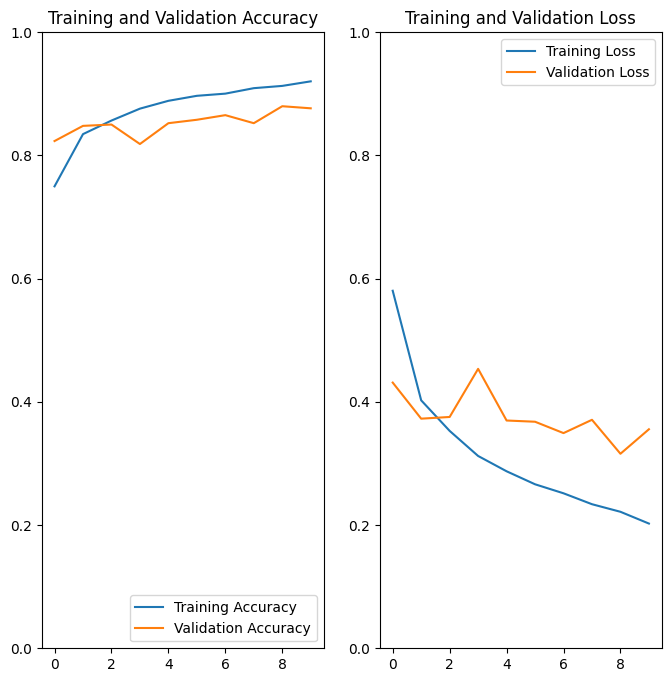

In [ ]:
# acc = history.history['accuracy']
# val_acc = history.history['val_accuracy']

# loss = history.history['loss']
# val_loss = history.history['val_loss']

# epochs_range = range(len(history.epoch))

# plt.figure(figsize=(8, 8))
# plt.subplot(1, 2, 1)
# plt.plot(epochs_range, acc, label='Training Accuracy')
# plt.plot(epochs_range, val_acc, label='Validation Accuracy')
# plt.ylim(0, 1)
# plt.legend(loc='lower right')
# plt.title('Training and Validation Accuracy')

# plt.subplot(1, 2, 2)
# plt.plot(epochs_range, loss, label='Training Loss')
# plt.plot(epochs_range, val_loss, label='Validation Loss')
# plt.ylim(0, 1)
# plt.legend(loc='upper right')
# plt.title('Training and Validation Loss')
# plt.show()


In [ ]:
# model.load_weights("./checkpoints/CNN_Model_20250403-083508.keras")

In [24]:
model.evaluate(test_ds)

Corrupt JPEG data: 419 extraneous bytes before marker 0xd9


130/130 ━━━━━━━━━━━━━━━━━━━━ 47s 55ms/step - accuracy: 0.8996 - loss: 0.2596


[0.25819268822669983, 0.9019277095794678]

In [ ]:
 
import numpy as np

# Utiliser les vraies classes détectées dans le dataset
# Assurez-vous que `class_names` est défini à partir de votre dataset
# Exemple : class_names = dataset.class_names
print(f"Classes disponibles : {class_names}")

model = tf.keras.models.load_model('./models/'+model_name+'.keras')
model.load_weights('./checkpoints/CNN_Model_20250407-200850.keras')
# Charger l'image
img_path = 'peinture_vernon.jpg'  # Remplacez par le chemin de votre image
img = tf.keras.image.load_img(img_path, target_size=(img_height, img_width)) 

# Prétraiter l'image
img_array = tf.keras.image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)  # Ajouter une dimension pour le batch

# Faire une prédiction
predictions = model.predict(test_ds)

# Trouver l'indice de la classe avec la probabilité la plus élevée
predicted_class_index = np.argmax(predictions[0])

# Afficher le nom de la classe prédite
predicted_class_name = class_names[predicted_class_index]
print(f"Classe prédite : {predicted_class_name}")

NameError: name 'class_names' is not defined